# Lab Sheet 3

In [ ]:
from header import *

# %matplotlib widget

Exercise 1.1

Here we plot $y=2e^{-t}\sin(30t)$ against $t$.  This oscillates and dies away, like the motion of a guitar string after it has been plucked.

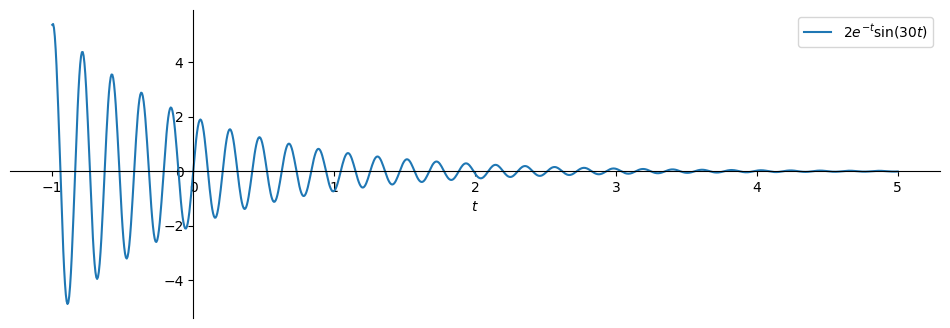

In [3]:
ts = np.linspace(-1,5,1000)         # array of values of t
ys = 2 * np.exp(-ts)*np.sin(30*ts)  # corresponding values of y
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlabel('$t$')
ax.plot(ts, ys, label=r'$2e^{-t} \sin(30t)$')
fix_axes(ax)
ax.legend() # This is needed to display the label


Here we plot $y=2\sin(20t)+3\sin(21t)$ against $t$.  This is a sum of two signals of slightly different frequencies; musicians will be familiar with the resulting effect.  The combined signal oscillates rapidly (at the same frequency as $\sin(20.5t)$), with the size of the oscillations varying more slowly  (like $\cos(t)$).

<Axes: >

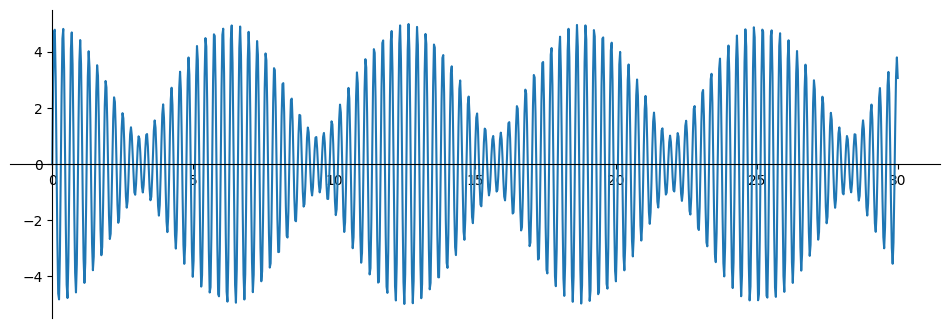

In [4]:
ts = np.linspace(0,30,1000)
ys = 2 * np.sin(20*ts) + 3 * np.sin(21*ts)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts, ys)
fix_axes(ax)


Here we plot $y=\sin(x)+\sin(3x)/3+\sin(5x)/5+\sin(7x)/7$ against $x$.  Half the time this wiggles around near $y = 0.8$, and half the time it wiggles around near $y = -0.8$.  It jumps quite rapidly between the two levels, and the jumps occur at multiples of $\pi$.

<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Neil\AppData\Local\Temp\ipykernel_11232\1329064922.py:5: SyntaxWarning: invalid escape sequence '\p'
  ax.xaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%g $\pi$'))


<Axes: >

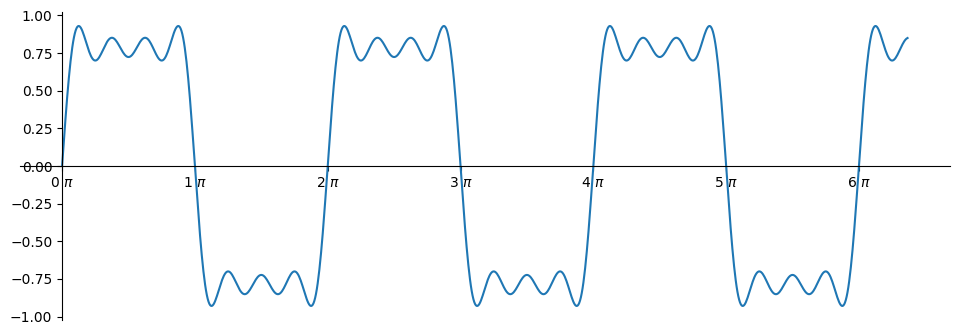

In [5]:
xs = np.linspace(0,20,1000)
ys = np.sin(xs) + np.sin(3*xs)/3 + np.sin(5*xs)/5 + np.sin(7*xs)/7
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(xs/np.pi, ys)
ax.xaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%g $\pi$'))
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(base=1))
fix_axes(ax)


Here we plot $y=\cos(\pi x^2)$ against $x$.  The function oscillates between $-1$ and $1$, with the oscillations becoming more and more rapid as the absolute value of $x$ increases.

<Axes: >

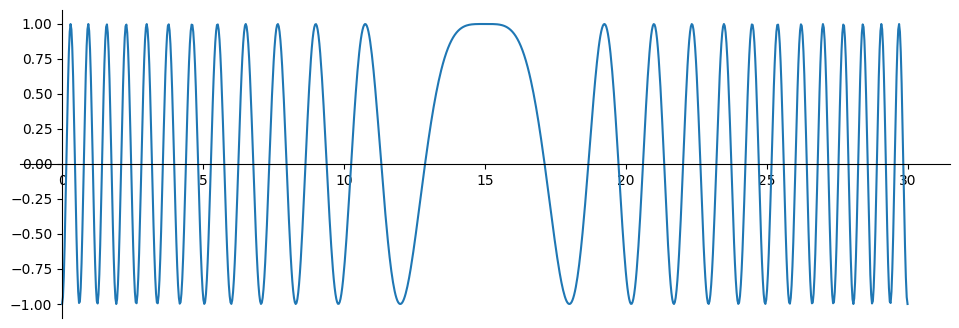

In [6]:
xs = np.linspace(-5,5,1000)
ys = np.cos(np.pi * xs**2)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts, ys)
fix_axes(ax)


Exercise 1.2

We now investigate the function $f(x)=(x^3-x)(x^2-4/9)(x^2-1/9)$.

In [7]:
x = sp.symbols('x')
f = (x**3 - x) * (x**2 - sp.Rational(4,9)) * (x**2 - sp.Rational(1,9))
display(f)
f1 = sp.lambdify(x, f, 'numpy')

(x**2 - 4/9)*(x**2 - 1/9)*(x**3 - x)

The graph of $f(x)$ is quite flat and close to zero between $x=-1$ and $x=1$, crossing the $x$-axis seven times, at $x=-1,-\frac{2}{3},-\frac{1}{3},0,\frac{1}{3},\frac{2}{3}$ and $1$.  The function increases rapidly towards $\infty$ for $x>1$, and drops rapidly towards $-\infty$ fo $x<-1$.

The rate of growth is similar to $x^7$, and in fact $f(x)$ is indistinguishable from $x^7$ when $x$ is reasonably large.

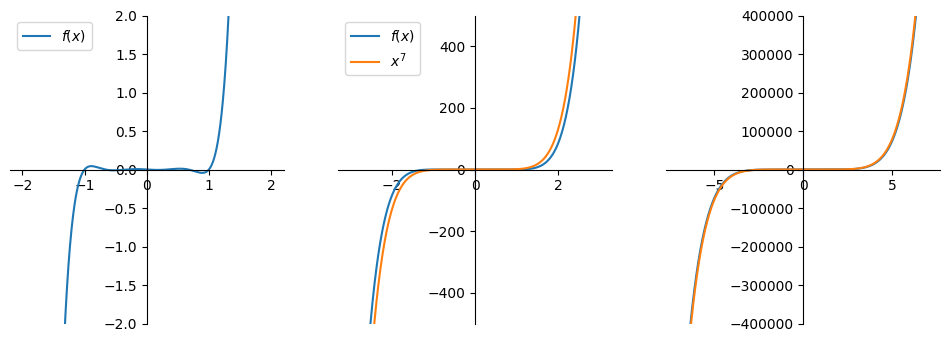

In [8]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
xs = np.linspace(-2,2,1000)
ys = f1(xs)
ax[0].set_ylim(-2,2)
ax[0].plot(xs, ys, label=r'$f(x)$')
ax[0].legend()
xs = np.linspace(-3,3,1000)
ys = f1(xs)
ax[1].set_ylim(-500,500)
ax[1].plot(xs, ys, label=r'$f(x)$')
ax[1].plot(xs, xs ** 7, label=r'$x^7$')
ax[1].legend()
xs = np.linspace(-7,7,1000)
ys = f1(xs)
ax[2].set_ylim(-4e5,4e5)
ax[2].plot(xs, ys)
ax[2].plot(xs, xs ** 7)
for i in range(3):
    fix_axes(ax[i])


To see the reason for this, just expand out $f(x)$.  The leading term is $x^7$, and the remaining terms are multiples of $x^5$ or lower, so they are much smaller than $x^7$ when $x$ is large.


In [9]:
sp.expand(f)

x**7 - 14*x**5/9 + 49*x**3/81 - 4*x/81

In [10]:
del x, f, f1, xs, ys

Exercise 1.3

Here we investigate the function $g(x)=\frac{2x-3}{3x-4}$.

In [11]:
x, y = sp.symbols('x y')
g = lambda x: (2 * x - 3)/(3*x - 4)
display(Latex("$g(x) = " + sp.latex(g(x)) + "$"))
g1 = sp.lambdify(x, g(x), 'numpy')

<IPython.core.display.Latex object>

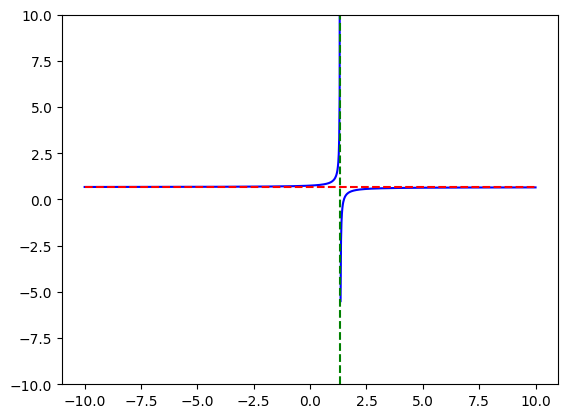

In [12]:
xs = np.linspace(-10,10,1000)
ys = g1(xs)
plt.ylim(-10,10)
plt.plot(xs[xs<4/3], ys[xs<4/3],'b-')     # plot the part of the graph where x < 4/3
plt.plot(xs[xs>4/3], ys[xs>4/3],'b-')     # plot the part of the graph where x > 4/3
plt.plot([xs[0],xs[-1]],[2/3,2/3],'r--')  # horizontal line at y=2/3
plt.plot([4/3,4/3],[-10,10],'g--')        # vertical line at x=4/3


Most of the time the graph is very flat, and close to $y=0.7$.  Somewhere close to $x=1.3$, the graph climbs steeply to $\infty$, jumps down discontinuously to $-\infty$, and then climbs back up to around $0.7$ again.

The function is discontinuous at the point where the formula $g(x)=\frac{2 x -3}{3 x -4}$ involves division by zero, which means $3x-4=0$ or in other words $x=\frac{4}{3}$.

The picture shows that the graph does not cross the line $y=\frac{2}{3}$.  To see this algebraically, we first find the general formula for the point where the curve crosses the line 
$y=a$.


In [13]:
a = sp.symbols('a')
g_inv = sp.lambdify(a, sp.solve(sp.Eq(g(y),a),[y])[0])
display(g_inv(a))

(4*a - 3)/(3*a - 2)

The formula involves division by zero when $a=\frac{2}{3}$, indicating that the curve does not in fact cross the line $y=\frac{2}{3}$.

We now find the limit of $g(x)$ as $x\to\pm\infty$.

In [14]:
sp.limit(g(x), x, sp.oo), sp.limit(g(x), x, -sp.oo)

(2/3, 2/3)

This is of course the same answer as in (c).  As $x$ approaches $\infty$, the function $g (x)$ approaches $\frac{2}{3}$ from below, but never reaches it.  As $x$ approaches $-\infty$, the function approaches $\frac{2}{3}$ from above, but again never reaches it.


In [15]:
del x, y, a, g, g1, g_inv, xs, ys

Exercise 1.4

Here we investigate the function $f(x)=\frac{1-e^x+e^{2x}-e^{3x}}{\sin(x)}$, including the limit as $x$ approaches zero.

In [16]:
x = sp.symbols('x')
f = (1 - sp.exp(x) + sp.exp(2*x) - sp.exp(3*x))/sp.sin(x)
display(f)
f1 = sp.lambdify(x, f, 'numpy')


(-exp(3*x) + exp(2*x) - exp(x) + 1)/sin(x)

<Axes: >

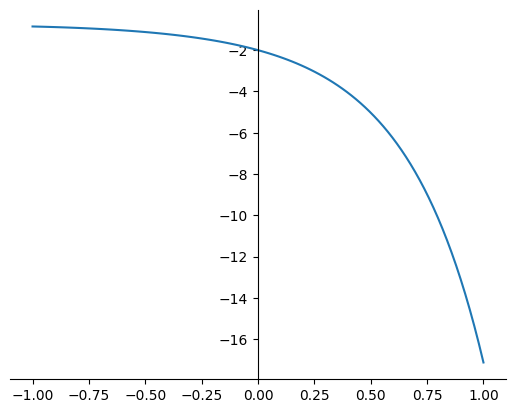

In [17]:
xs = np.linspace(-1,1,100)
ys = f1(xs)
plt.plot(xs, ys)
fix_axes(plt.gca())

Although the formula for $f(x)$ does not make sense when $x=0$, the only reasonable definition is $f(0)=-2$, as we see from the graph.  Here is a non-graphical way to get sympy to produce this answer:

In [18]:
sp.limit(f,x,0)

-2

To do this by hand we can use L'Hôpital's rule:
$$ \lim_{x\to 0} \frac{1-e^x+e^{2x}-e^{3x}}{\sin(x)} = 
   \lim_{x\to 0} \frac{-e^x+2e^{2x}-3e^{3x}}{\cos(x)} = 
   \frac{-e^0+2e^0-3e^0}{\cos(0)} = \frac{-2}{1} = -2.
$$

In [19]:
del x, f, f1, xs, ys

Exercise 1.5

Here we investigate the Bessel function $J_2(x)$, which often appears in physical problems involving circular symmetry.  For symbolic properties of $J_2(x)$ it is best to use the sympy version of this function, which is `sp.functions.special.besselj(2,x)`.  For numerical calculations it is better to use the scipy implementation, which is `sc.special.jv(2,x)`.  We first make abbreviate names for these.

In [20]:
x = sp.symbols('x')
J2 = lambda x: sp.functions.special.bessel.besselj(2, x)  # sympy version
J2n = lambda x: sc.special.jv(2, x)                       # scipy version
J2(x)


besselj(2, x)

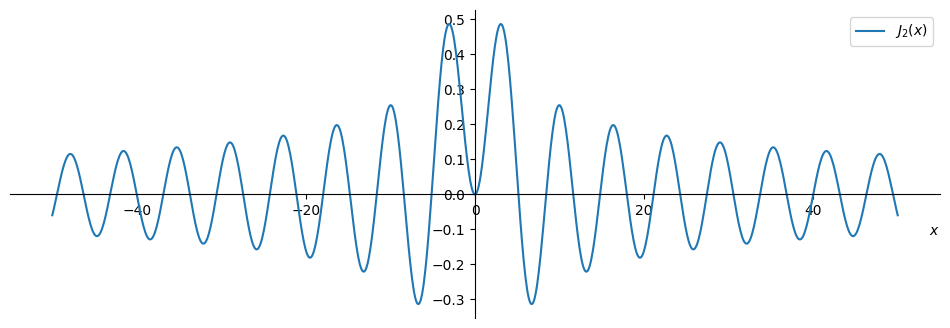

In [21]:
xs = np.linspace(-50,50,1000)
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlabel('$x$', loc='right')
ax.plot(xs, J2n(xs), label=r'$J_2(x)$')
fix_axes(ax)
ax.legend()

The Bessel function is even (i.e. $J_{2}(-x)=J_{2}(x)$).  It oscillates quite regularly, with amplitude decreasing slowly as $x$ approaches $\infty$ or $-\infty$.

For small $x$, the function $J_{2}(x)$ is very close to $\frac{x^{2}}{8}$, as shown by the plot below.

<Axes: >

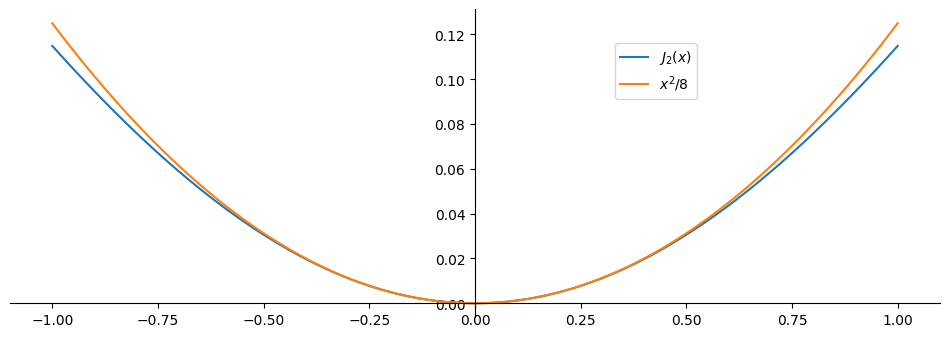

In [22]:
xs = np.linspace(-1,1,100)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(xs, J2n(xs), label=r'$J_2(x)$')
ax.plot(xs, xs ** 2 / 8, label=r'$x^2/8$')
ax.legend(loc=(0.65,0.71))
fix_axes(ax)


The upper envelope of the oscillation is $y=0.8 x^{-\frac{1}{2}}$, as shown by the plot below.


<Axes: >

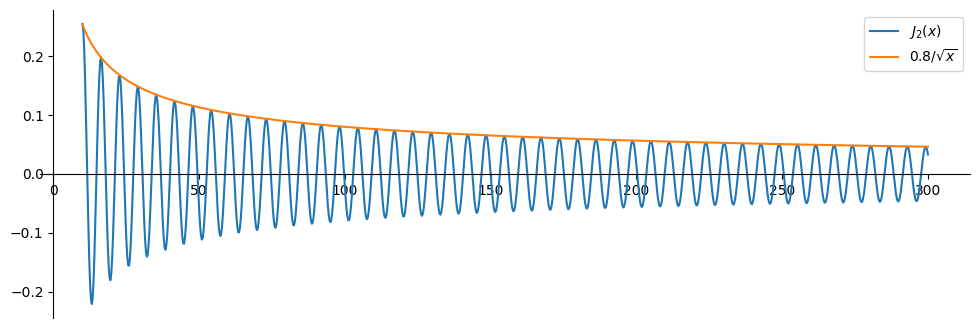

In [23]:
xs = np.linspace(10,300,1000)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(xs, J2n(xs), label=r'$J_2(x)$')
ax.plot(xs, 0.8 / np.sqrt(xs), label=r'$0.8/\sqrt{x}$')
ax.legend()
fix_axes(ax)


The plot below shows that $J_{2}(x)$ has (to a very good approximation) the same frequency as $\sin (x)$.

<Axes: >

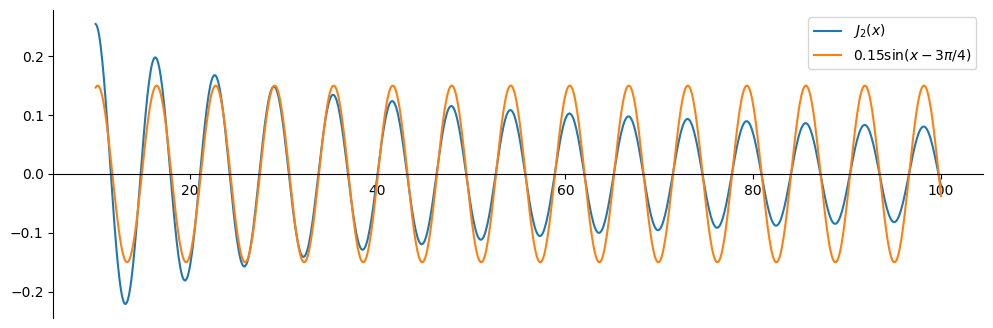

In [24]:
xs = np.linspace(10,100,1000)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(xs, J2n(xs), label=r'$J_2(x)$')
ax.plot(xs, 0.15 * np.sin(xs - 3*np.pi/4), label=r'$0.15 \sin(x - 3\pi/4)$')
ax.legend()
fix_axes(ax)


By combining the above results, we see that the function $\frac{4}{5}x^{-1/2}\sin(x-3\pi/4)$ should be a good approximation to 
$J_{2}(x)$ for large $x$.  The plot below shows this graphically.


<Axes: >

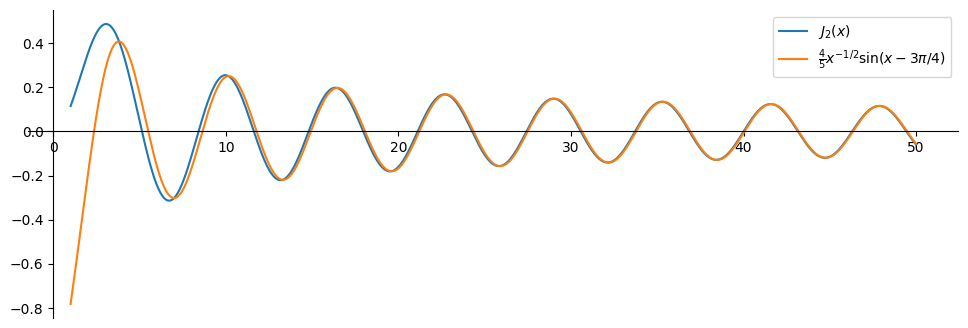

In [25]:
xs = np.linspace(1,50,1000)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(xs, J2n(xs), label=r'$J_2(x)$')
ax.plot(xs, np.sin(xs - 3*np.pi/4) * 4 / (5 * np.sqrt(xs)), label=r'$\frac{4}{5}x^{-1/2}\sin(x - 3\pi/4)$')
ax.legend()
fix_axes(ax)


In [26]:
del x, J2, J2n, xs

Exercise 1.6

Here we investigate the function $g(a,x)$ defined below.

In [27]:
a, x = sp.symbols('a x')
g = (x-1-sp.sin(a/4))*(x-1-sp.cos(a/4))* (x+1-sp.sin(a/4))*(x+1-sp.cos(a/4))/(1+x**4)
display(Latex("$$g(a, x) = " + sp.latex(g) + "$$"))
g1 = sp.lambdify((a,x), g, 'numpy')

<IPython.core.display.Latex object>

The graph  $y=g(2,x)$ approaches $y=1$ very closely when $x$ is very large (positive or negative).  Close to $x=0$ it climbs quickly to about $y=2.5$, then drops very quickly to about $y=0$, then climbs again to just below $y=1$.  The graphs for $g(3,x)$ and $g(4,x)$ look very similar on this scale.

<Axes: >

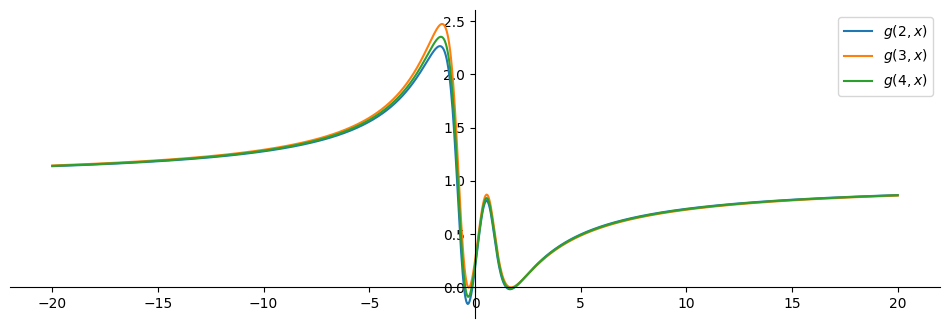

In [28]:
xs = np.linspace(-20,20,1000)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(xs, g1(2, xs), label='$g(2,x)$')
ax.plot(xs, g1(3, xs), label='$g(3,x)$')
ax.plot(xs, g1(4, xs), label='$g(4,x)$')
ax.legend()
fix_axes(ax)


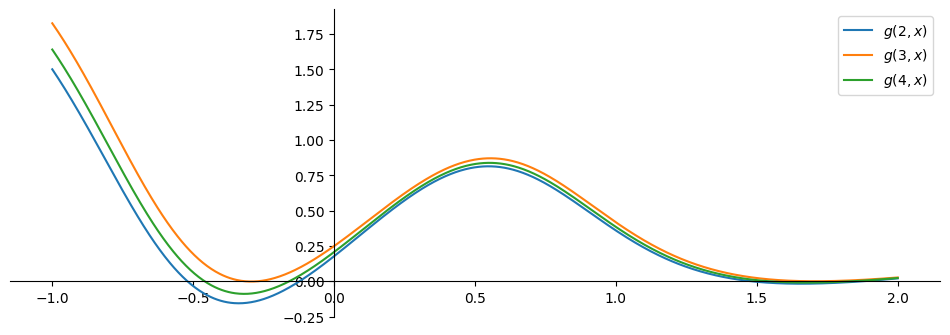

In [29]:
xs = np.linspace(-1,2,1000)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(xs, g1(2, xs), label=r'$g(2,x)$')
ax.plot(xs, g1(3, xs), label=r'$g(3,x)$')
ax.plot(xs, g1(4, xs), label=r'$g(4,x)$')
fix_axes(ax)
ax.legend()

It works out that the graph of $g(\pi,x)=g(3.1415927,x)$ stays above the $x$-axis, just touching it in two places.  We first show this graphically:

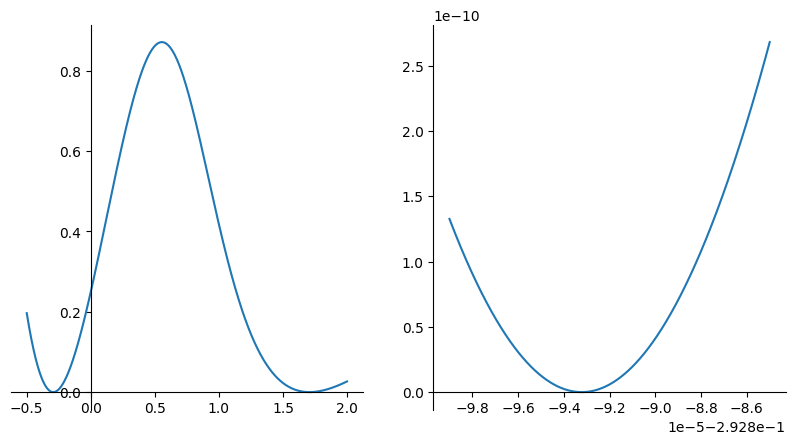

In [30]:
xs0  = np.linspace(-0.5,2,1000)
ys0 = g1(np.pi, xs0)
xs1 = np.linspace(-0.292899,-0.292885,1000)
ys1 = g1(np.pi, xs1)

fig, ax = plt.subplots(1,2, figsize=(10, 5)) 
ax[0].plot(xs0, ys0)
ax[1].plot(xs1, ys1)
for i in range(2):
    fix_axes(ax[i])


To see why this works algebraically, note that $\sin(\frac{\pi}{4})=\frac{\sqrt{2}}{2}$ and $\cos(\frac{\pi}{4})=\frac{\sqrt{2}}{2}$.  Putting this in the definition of $g(a,x)$ gives the following:


In [31]:
sp.simplify(g.subs({a : sp.pi}))

(-2*x + sqrt(2) + 2)**2*(2*x - sqrt(2) + 2)**2/(16*(x**4 + 1))

As the square or fourth power of any real number is nonnegative, this formula shows that $g(\pi,x)\geq 0$ for all $x$.


It also turns out that $1-8 g(a,0)=\cos (a)$.  

In [32]:
sp.simplify(1 - 8 * g.subs({x : 0}))

cos(a)

To do this simplification by hand, note that 
$$ \left(-1-\cos (\frac{a}{4})\right)\left(1-\cos (\frac{a}{4})\right)=\cos (\frac{a}{4})^{2}-1, $$
which is the same as $-\sin (\frac{a}{4})^{2}$.  Similarly, we have 
$$ \left(-1-\sin (\frac{a}{4})\right)\left(1-\sin (\frac{a}{4})\right)=-\cos (\frac{a}{4})^{2}. $$  
Putting these together, we see that 
$$ 8 g (a ,0)=8 \sin(\frac{a}{4})^{2} \cos(\frac{a}{4})^{2}, $$ 
which is the same as $2 (2 \sin (\frac{a}{4}) \cos (\frac{a}{4}))^{2}$.  Using the standard formula 
$\sin (2 \theta)=2 \sin (\theta) \cos (\theta)$, this simplifies to 
$2 \sin (\frac{a}{2})^{2}$.  We can then use the standard formula 
$\cos (2 \varphi)=1-2 \sin (\varphi)^{2}$ to deduce that 
$1-8 g (a ,0)=\cos (a)$. 


<Axes: >

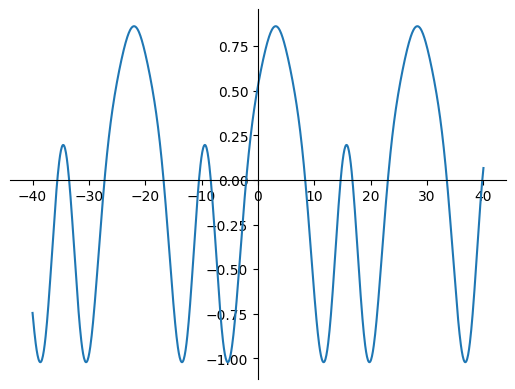

In [33]:
aa = np.linspace(-40,40,1000)
plt.plot(aa, g1(aa, 0.5))
fix_axes(plt.gca())

In [34]:
h = g.subs({x : sp.Rational(1,2)})
slope = sp.diff(h, a)
slope

4*(3/2 - sin(a/4))*(3/2 - cos(a/4))*(-sin(a/4) - 1/2)*sin(a/4)/17 - 4*(3/2 - sin(a/4))*(3/2 - cos(a/4))*(-cos(a/4) - 1/2)*cos(a/4)/17 + 4*(3/2 - sin(a/4))*(-sin(a/4) - 1/2)*(-cos(a/4) - 1/2)*sin(a/4)/17 - 4*(3/2 - cos(a/4))*(-sin(a/4) - 1/2)*(-cos(a/4) - 1/2)*cos(a/4)/17

In [35]:
[slope.subs({a : n * sp.pi}) for n in [-7, 1, 9]]

[0, 0, 0]

To make the cell below work, uncomment the `%matplotlib` line at the top of the file, uncomment the plot line below, restart and run the whole notebook.

In [ ]:
aa0 = np.linspace(-20,20,200)
xx0 = np.linspace(-10,10,500)
aa, xx = np.meshgrid(aa0, xx0)
yy = g1(aa, xx)

fig = go.Figure(data=[go.Surface(x=aa, y=xx, z=yy, colorscale='viridis')])
fig.update_layout(
    scene=dict(
        xaxis=dict(showticklabels=False),
        yaxis=dict(showticklabels=False),
        zaxis=dict(showticklabels=False),
        xaxis_title='',
        yaxis_title='',
        zaxis_title=''
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()